# Grid DAM: Multiscale Tradeoff and Encoder Sensitivity

Dense Associative Memory on multiscale grid-code encodings.

- **Identification**: retrieve the stored pattern from a noisy encoding of the same point.
- **Generalization**: retrieve the nearest stored pattern from a novel test point.

Main finding: generalization peaks near scale factor `c ≈ √e ≈ 1.65` while identification rises with larger `c`.

Set `QUICK_MODE = True` for a fast smoke run. Set `QUICK_MODE = False` for the full parameter grid.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
HANDOFF_ROOT = NOTEBOOK_DIR
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / "notebooks").is_dir() and (candidate / "vision").is_dir() and (candidate / "core").is_dir():
        HANDOFF_ROOT = candidate
        break
if str(HANDOFF_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(HANDOFF_ROOT.parent))

from handoff.lib.paths import ensure_handoff_paths

ensure_handoff_paths()

from experiments import get_generalization_optimum_c
from handoff.lib import grid_defaults as defaults
from handoff.lib.grid_runner import (
    load_multiscale_results,
    make_structure_preservation_figure,
    run_breakit_section,
    run_multiscale_sweep,
    run_structure_preservation,
    save_multiscale_results,
)

QUICK_MODE = False
LOAD_EXISTING = False
SEED = 0
OUTPUT_DIR = HANDOFF_ROOT / "results" / "grid"

if QUICK_MODE:
    SCALE_FACTORS = list(defaults.QUICK_SCALE_FACTORS)
    N_VALUES = list(defaults.QUICK_N_VALUES)
    K_VALUES = list(defaults.QUICK_K_VALUES)
    NUM_TRIALS = defaults.NUM_TRIALS_QUICK
else:
    SCALE_FACTORS = list(defaults.FULL_SCALE_FACTORS)
    N_VALUES = list(defaults.FULL_N_VALUES)
    K_VALUES = list(defaults.FULL_K_VALUES)
    NUM_TRIALS = defaults.NUM_TRIALS_FULL

BASE_ENCODER = dict(defaults.BASE_ENCODER)
N_VALUES_BREAKIT = defaults.N_VALUES_4B if not QUICK_MODE else list(defaults.QUICK_N_VALUES)
K_VALUES_BREAKIT = defaults.K_VALUES_4B if not QUICK_MODE else list(defaults.QUICK_K_VALUES)


def breakit_setting_values(experiment_name: str) -> list:
    spec = defaults.BREAKIT_EXPERIMENTS[experiment_name]
    return list(spec["quick_values"] if QUICK_MODE else spec["values"])


def run_breakit_cell(experiment_name: str) -> None:
    rows, _raw, figures = run_breakit_section(
        experiment_name,
        output_dir=OUTPUT_DIR / "breakit" / experiment_name,
        setting_values=breakit_setting_values(experiment_name),
        scale_factors=SCALE_FACTORS,
        n_values=N_VALUES_BREAKIT,
        K_values=K_VALUES_BREAKIT,
        base_encoder=BASE_ENCODER,
        num_trials=NUM_TRIALS,
        seed=SEED,
    )
    for row in rows:
        print(
            f"setting={row.setting_value}: c*={row.optimum_c:.3f}, "
            f"gen={row.gen_accuracy:.1f}%, ident={row.ident_accuracy:.1f}%"
        )
    for fig in figures:
        plt.show()

## What the multiscale experiment does

1. **Encoder:** build a multiscale grid code with `n_modules` modules. Module `m` uses frequency `base_freq * c^m`, where `c` is the scale factor.
2. **Memory:** store `K` encoded 2D points in a Dense Associative Memory. Vary the energy order `n` of the DAM.
3. **Identification:** add noise to a stored point, encode it, retrieve from memory. Success means the retrieved pattern is closest to the correct stored encoding.
4. **Generalization:** encode a new test point (not in memory), retrieve from memory. Success means the retrieved pattern matches the true nearest stored neighbor in 2D.
5. **Sweep:** vary `c`, `n`, and `K` and plot identification vs generalization accuracy. Generalization is strongest near `c ≈ √e ≈ 1.65`.

## Structure preservation

Before running DAM sweeps, check that encoded distances still correlate with 2D distances as `c` changes.

c=1.00: r=0.558
c=1.10: r=0.304
c=1.21: r=0.255
c=1.31: r=0.260
c=1.42: r=0.284
c=1.52: r=0.277
c=1.63: r=0.321
c=1.73: r=0.294
c=1.84: r=0.305
c=1.94: r=0.282
c=2.05: r=0.290
c=2.15: r=0.331
c=2.26: r=0.256
c=2.36: r=0.259
c=2.47: r=0.267
c=2.57: r=0.280
c=2.68: r=0.329
c=2.78: r=0.281
c=2.89: r=0.274
c=2.99: r=0.326
c=3.10: r=0.320
c=3.20: r=0.269


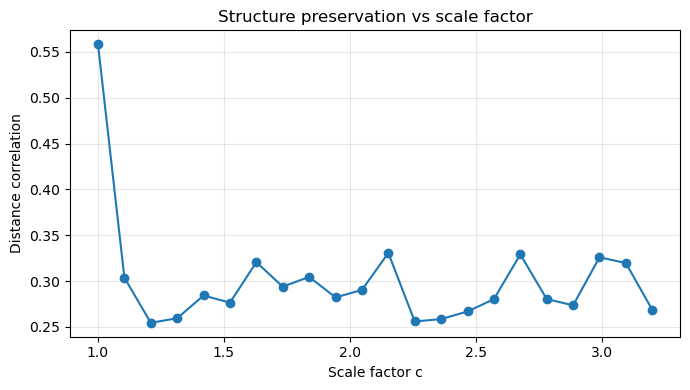

In [2]:
structure = run_structure_preservation(SCALE_FACTORS, seed=SEED)
for c, stats in structure.items():
    print(f"c={float(c):.2f}: r={stats['correlation']:.3f}")

structure_fig = make_structure_preservation_figure(structure)
plt.show()

## Multiscale ident/gen sweep

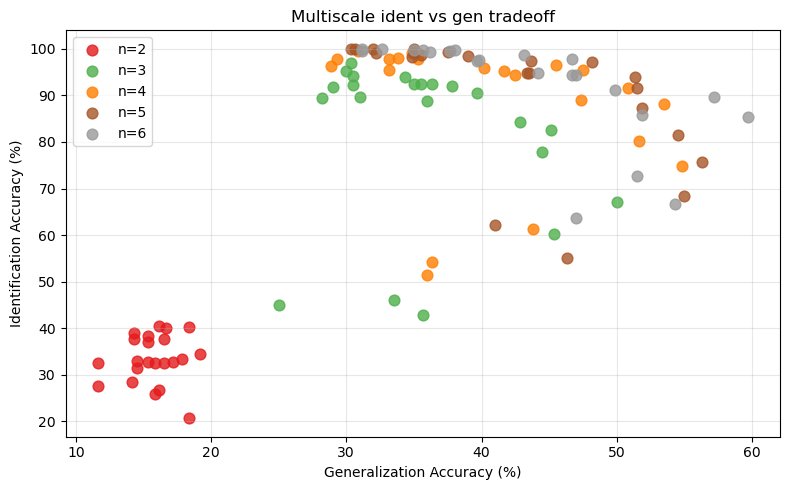

Saved multiscale artifacts under /Volumes/youwhat/projects/memgrid/handoff/results/grid/multiscale


In [3]:
multiscale_dir = OUTPUT_DIR / "multiscale"
if LOAD_EXISTING and (multiscale_dir / "ident_results.json").exists():
    ident_results, gen_results, config, multiscale_scale_factors = load_multiscale_results(multiscale_dir)
    from handoff.lib.grid_runner import make_multiscale_tradeoff_figure

    multiscale_fig = make_multiscale_tradeoff_figure(
        ident_results,
        gen_results,
        multiscale_scale_factors,
        N_VALUES,
        K_VALUES,
    )
else:
    multiscale_scale_factors = SCALE_FACTORS
    ident_results, gen_results = run_multiscale_sweep(
        scale_factors=SCALE_FACTORS,
        n_values=N_VALUES,
        K_values=K_VALUES,
        num_trials=NUM_TRIALS,
        seed=SEED,
    )
    config = {
        "scale_factors": SCALE_FACTORS,
        "n_values": N_VALUES,
        "k_values": K_VALUES,
        "num_trials": NUM_TRIALS,
        "quick_mode": QUICK_MODE,
    }
    _paths, multiscale_fig = save_multiscale_results(
        multiscale_dir,
        ident_results=ident_results,
        gen_results=gen_results,
        scale_factors=SCALE_FACTORS,
        n_values=N_VALUES,
        K_values=K_VALUES,
        config=config,
    )

plt.show()
print(f"Saved multiscale artifacts under {multiscale_dir}")

In [4]:
if 4 in N_VALUES:
    best_c, best_gen, best_ident = get_generalization_optimum_c(
        gen_results,
        ident_results,
        multiscale_scale_factors,
        N_VALUES,
        K_VALUES,
        n_for_opt=4,
    )
    print(f"n=4 optimum c={float(best_c):.3f}, gen={best_gen:.1f}%, ident={best_ident:.1f}%")
    print(f"Reference target c≈{np.sqrt(np.e):.3f}")

n=4 optimum c=1.314, gen=54.8%, ident=74.9%
Reference target c≈1.649


## Encoder sensitivity sweeps

Change one encoder parameter at a time and track the gen-optimal scale factor `c` at `n=4`. Each subsection runs all settings for that parameter, prints optimum values, displays one tradeoff plot per setting, and saves JSON/PNG under `handoff/results/grid/breakit/`.

### Orientations

setting=2: c*=1.524, gen=47.6%, ident=88.9%
setting=3: c*=1.419, gen=53.8%, ident=92.2%
setting=4: c*=1.733, gen=60.9%, ident=95.0%
setting=5: c*=1.105, gen=61.6%, ident=64.4%
setting=6: c*=1.524, gen=67.1%, ident=93.3%
setting=7: c*=1.733, gen=70.4%, ident=97.8%


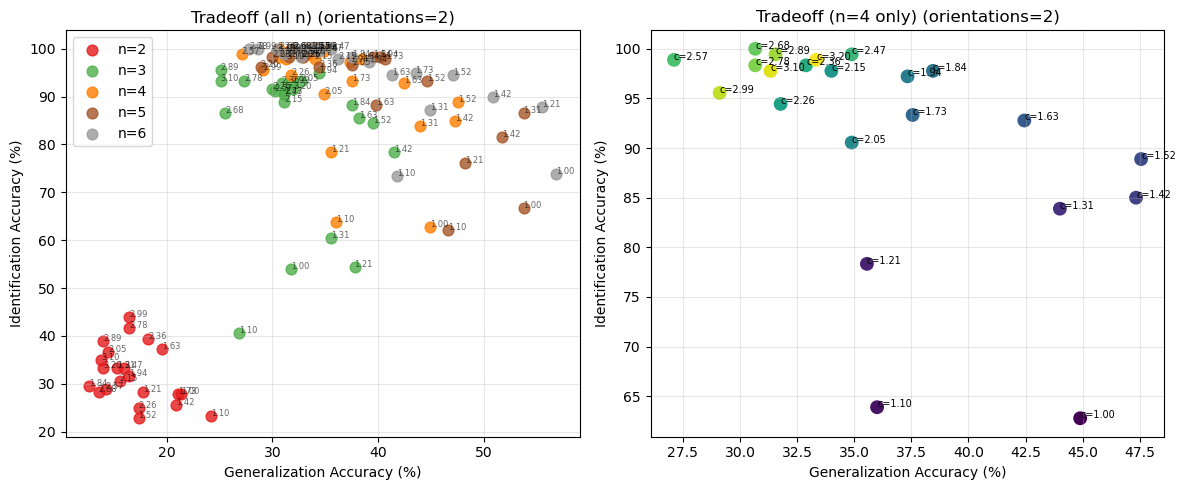

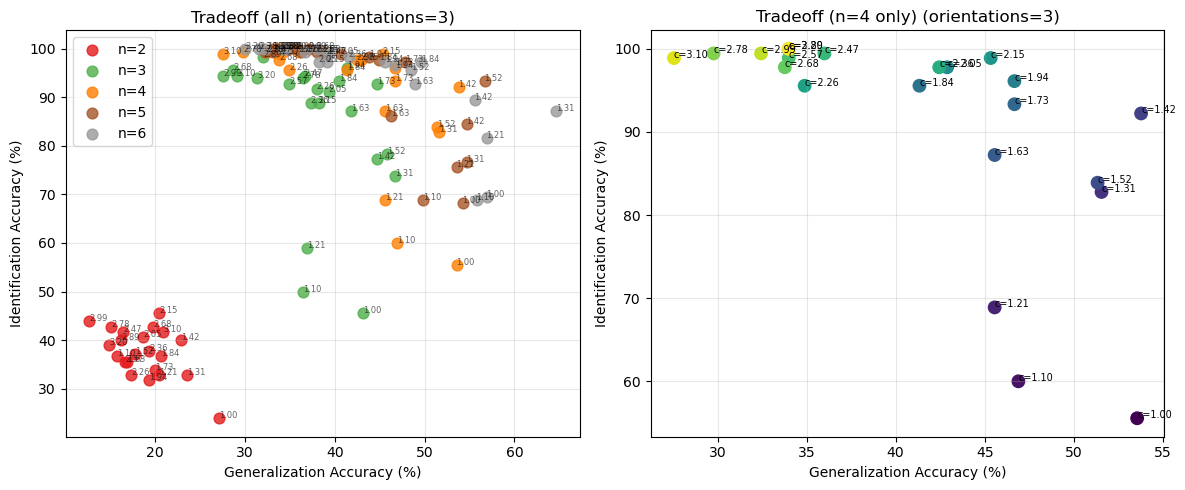

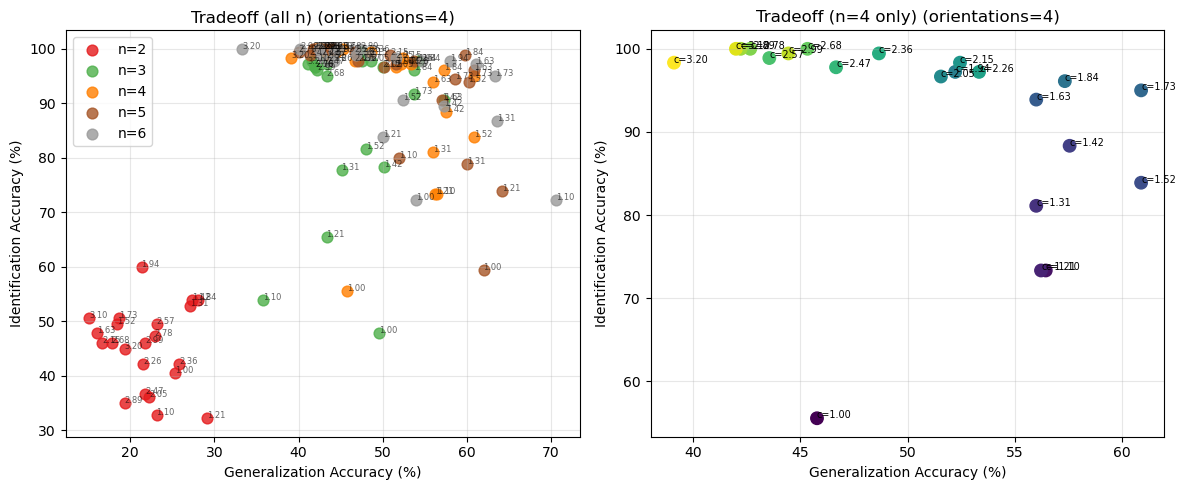

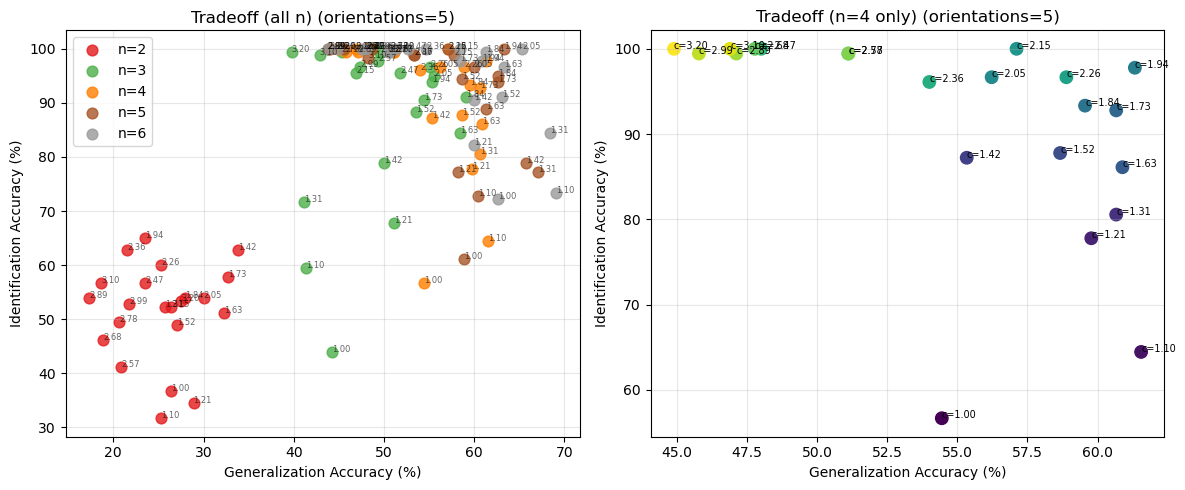

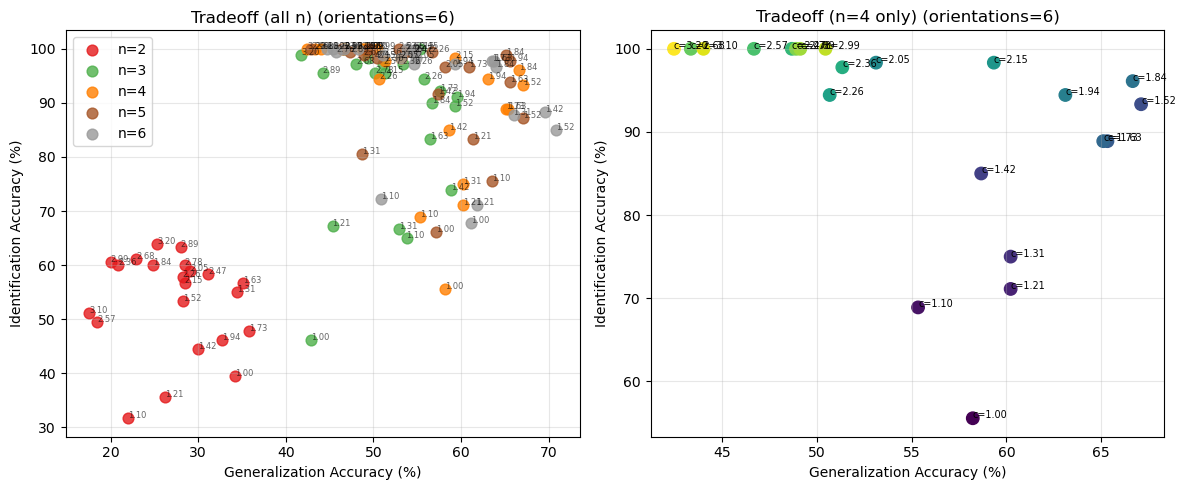

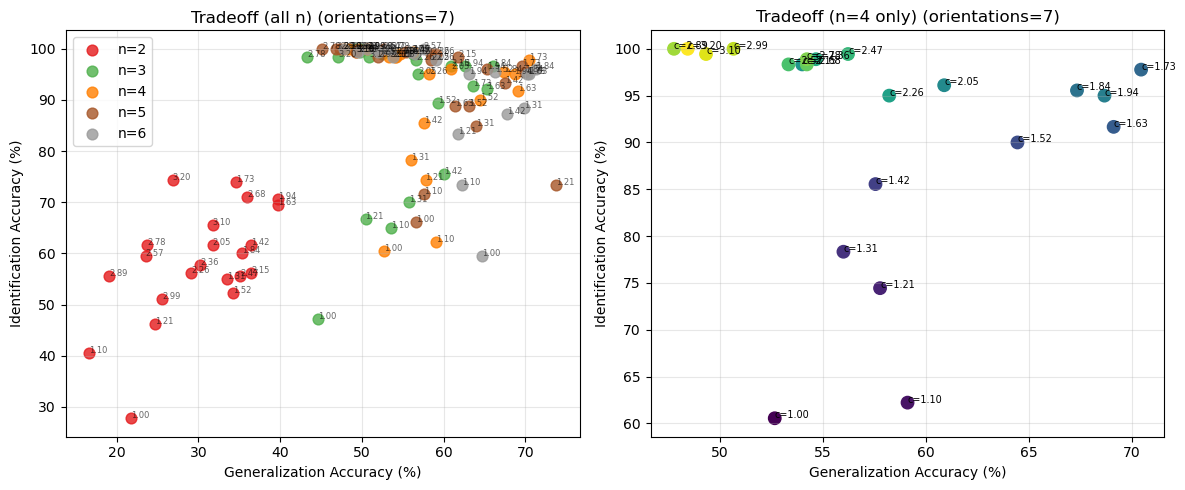

In [5]:
run_breakit_cell("orientations")

### Base frequency

setting=0.3: c*=1.733, gen=67.6%, ident=85.0%
setting=0.5: c*=1.419, gen=53.8%, ident=92.2%
setting=0.7: c*=1.419, gen=42.9%, ident=96.1%
setting=1.0: c*=1.210, gen=31.6%, ident=92.2%
setting=1.3: c*=1.210, gen=27.8%, ident=93.9%
setting=1.5: c*=1.210, gen=25.3%, ident=96.7%
setting=1.7: c*=1.210, gen=23.1%, ident=98.9%


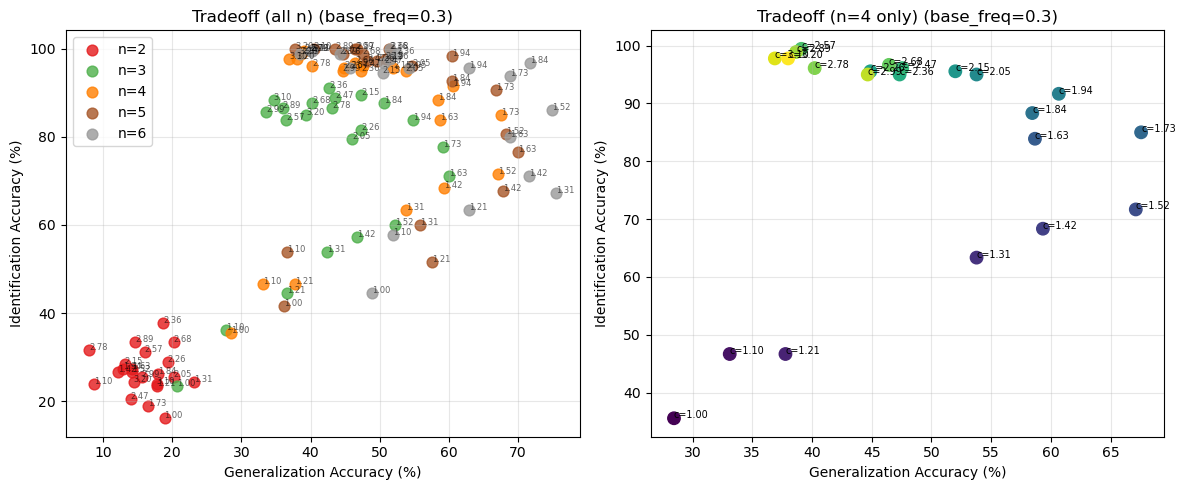

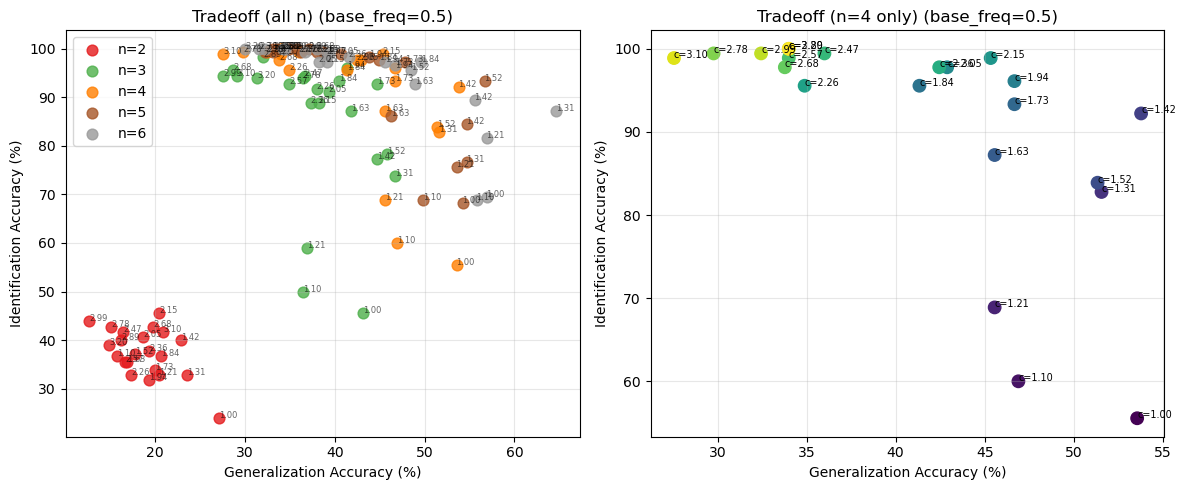

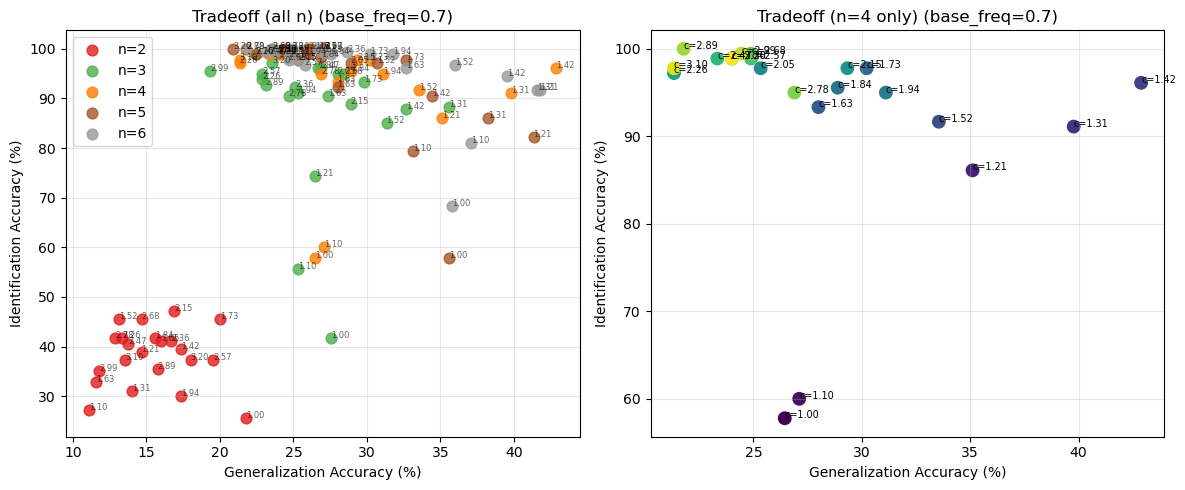

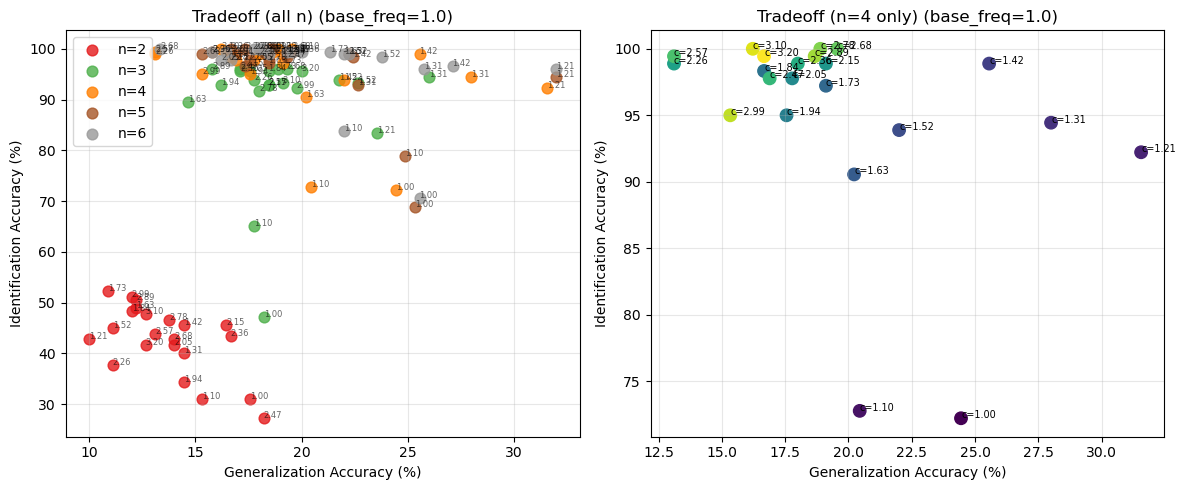

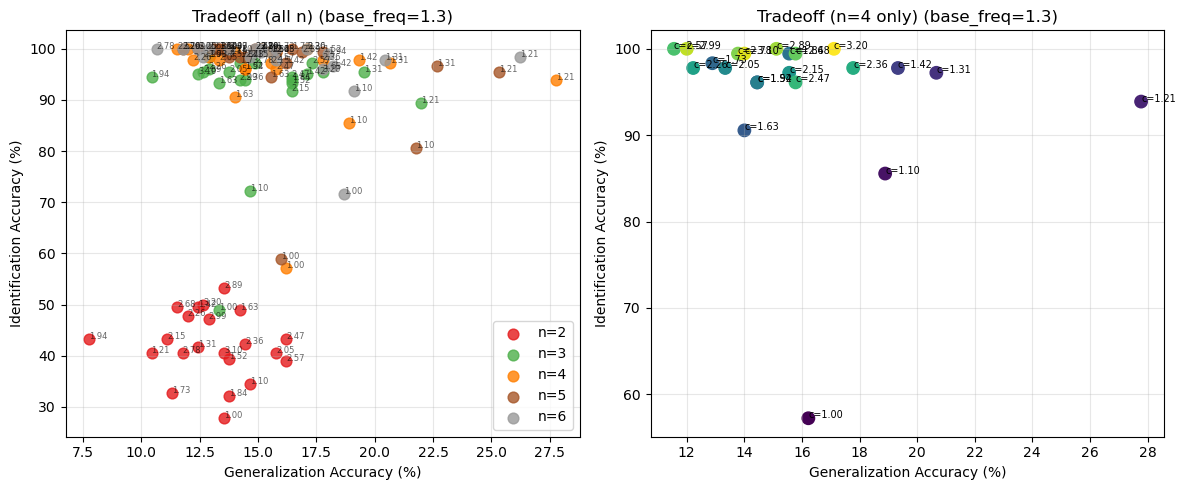

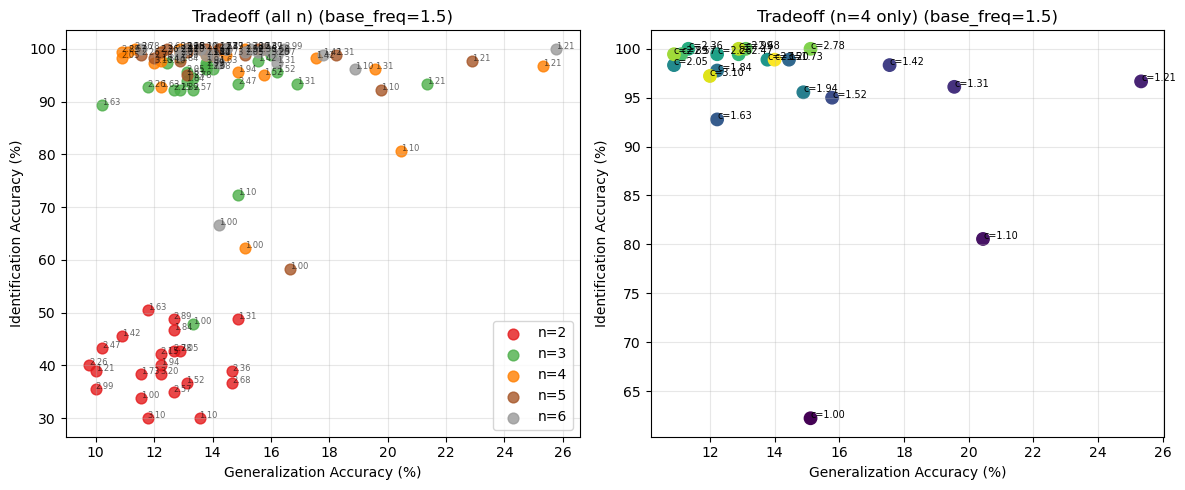

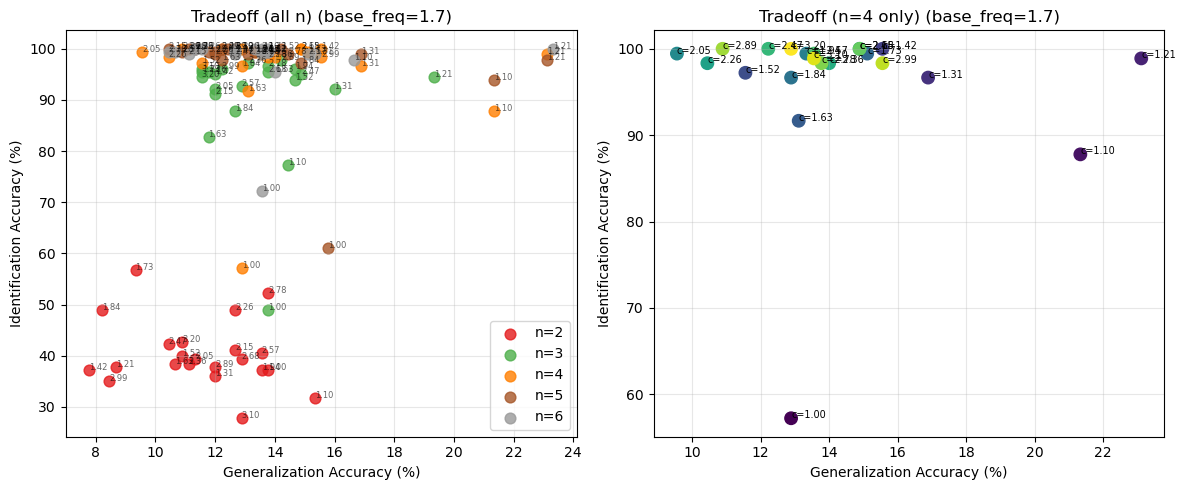

In [6]:
run_breakit_cell("base_freq")

### Modules

setting=3: c*=1.419, gen=61.1%, ident=76.7%
setting=4: c*=1.419, gen=53.8%, ident=92.2%
setting=5: c*=1.314, gen=54.2%, ident=82.8%
setting=6: c*=1.210, gen=56.0%, ident=83.3%
setting=7: c*=1.000, gen=48.7%, ident=41.7%
setting=8: c*=1.210, gen=55.1%, ident=86.7%
setting=9: c*=1.210, gen=52.0%, ident=93.3%


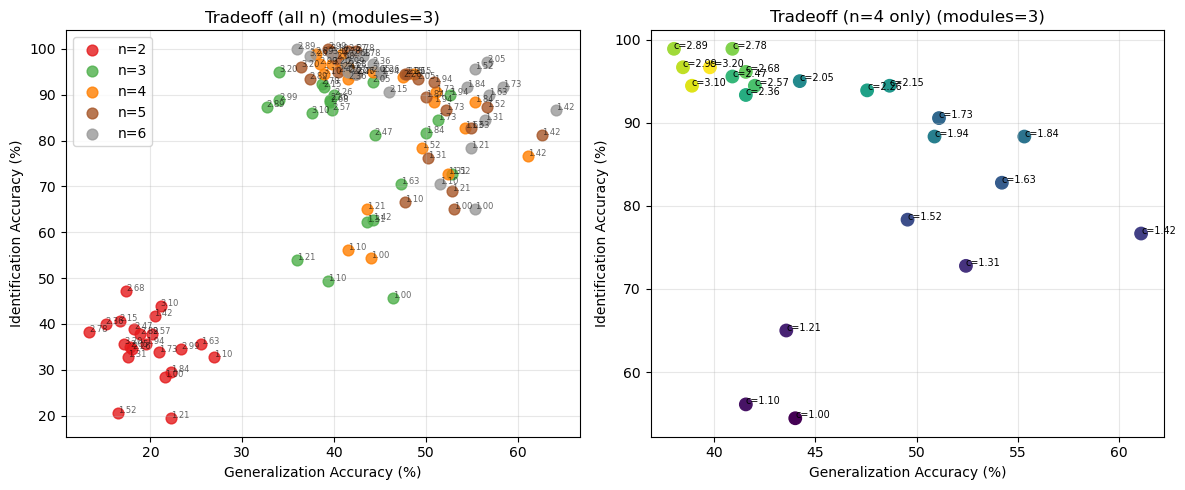

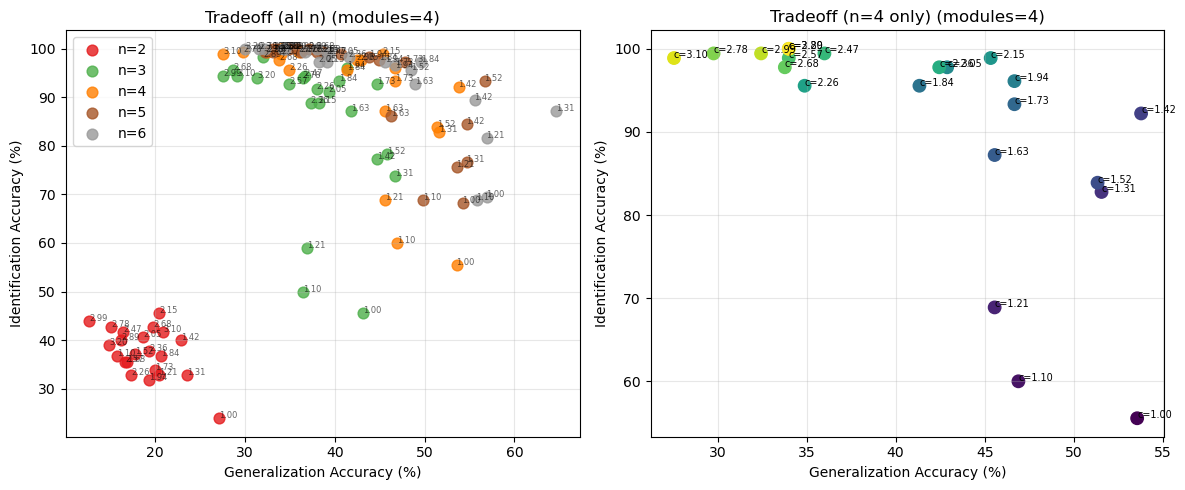

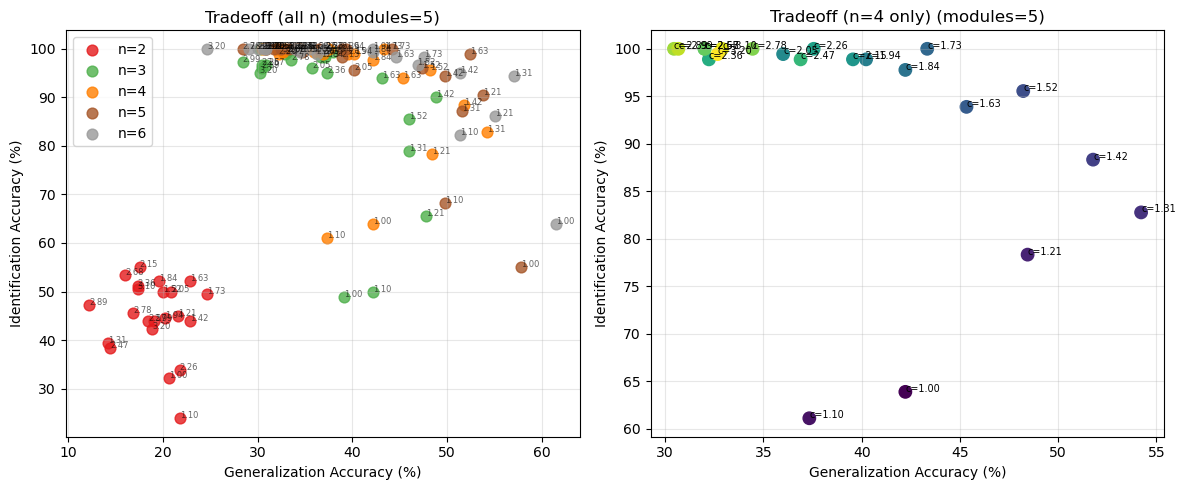

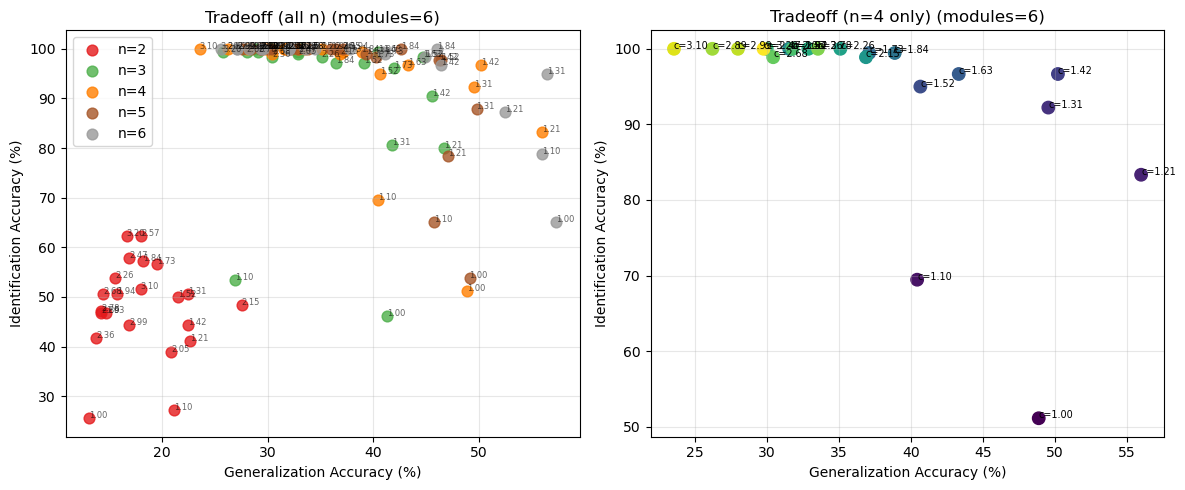

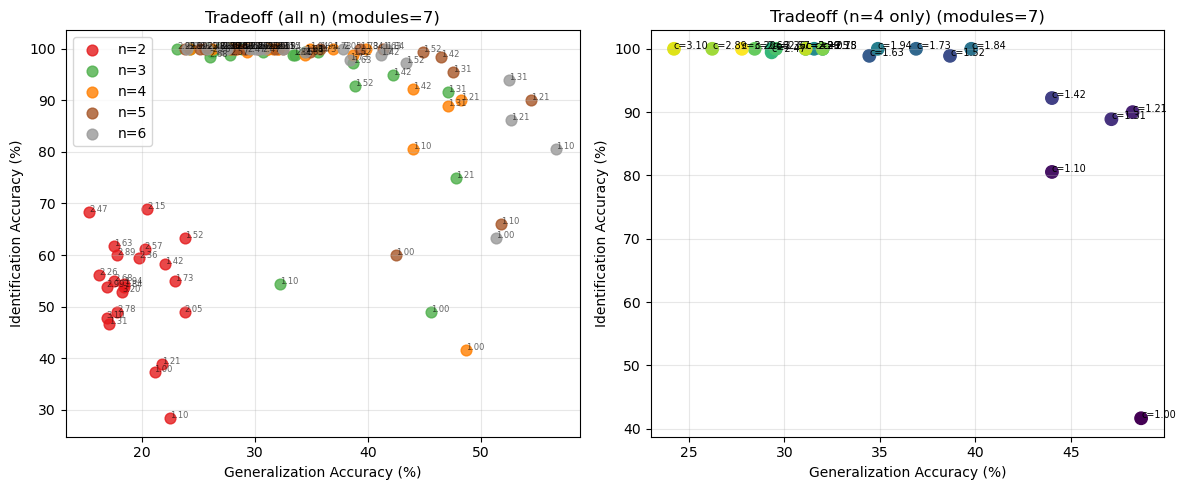

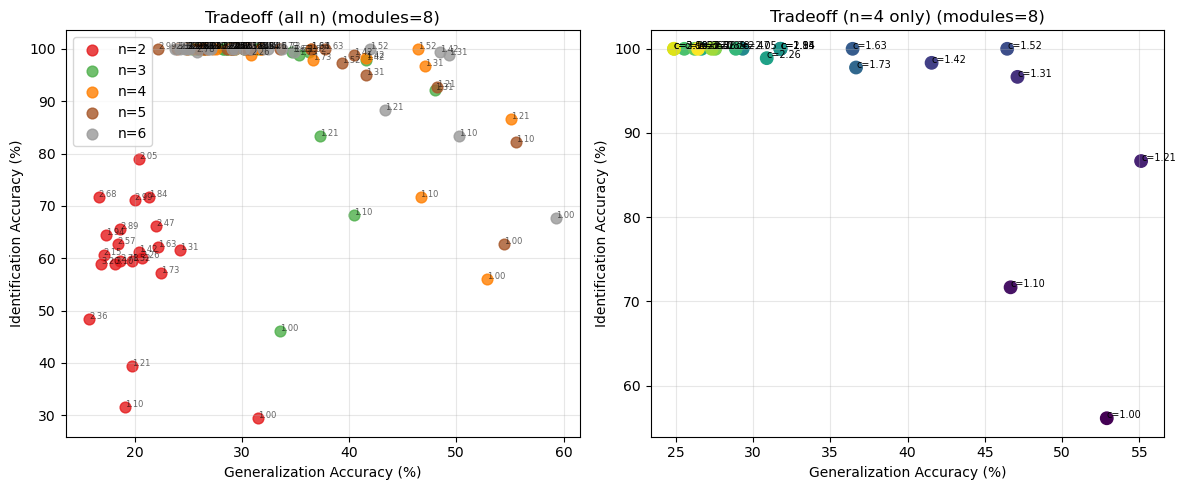

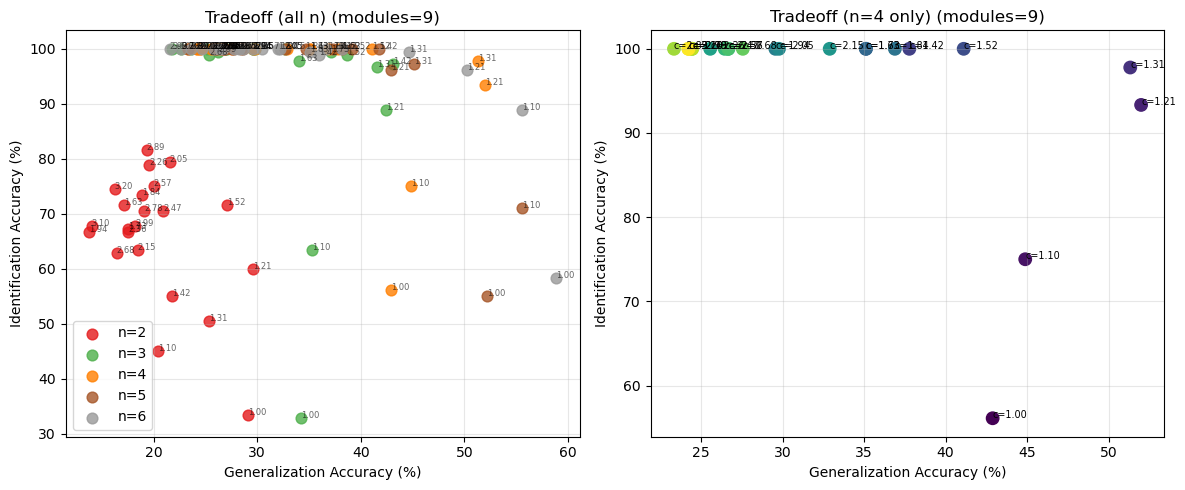

In [7]:
run_breakit_cell("modules")

### Cells per orientation

setting=1: c*=1.000, gen=58.7%, ident=69.4%
setting=3: c*=1.419, gen=57.3%, ident=78.9%
setting=5: c*=1.314, gen=53.1%, ident=76.7%
setting=7: c*=1.314, gen=54.2%, ident=80.0%
setting=9: c*=1.314, gen=56.7%, ident=74.4%


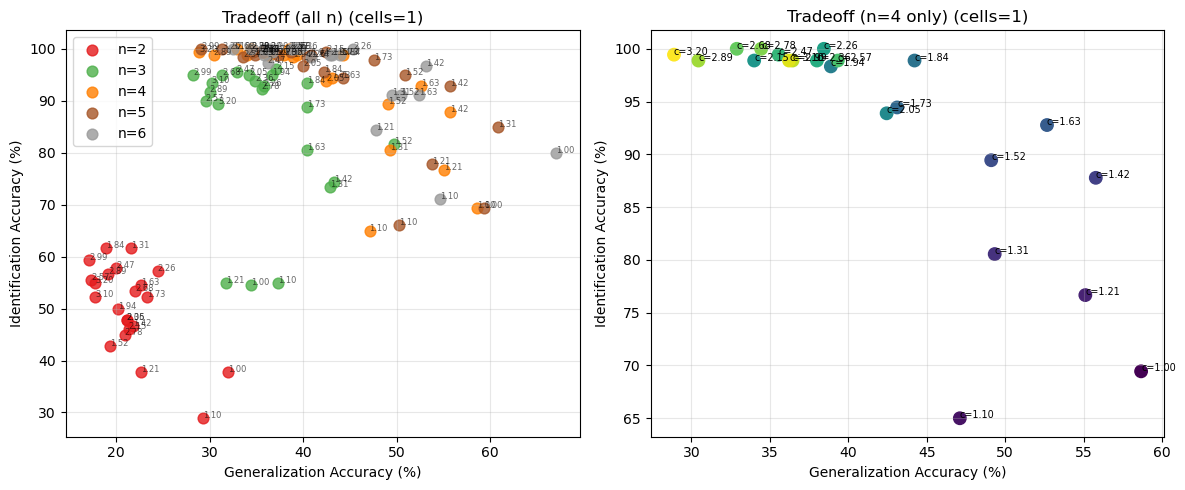

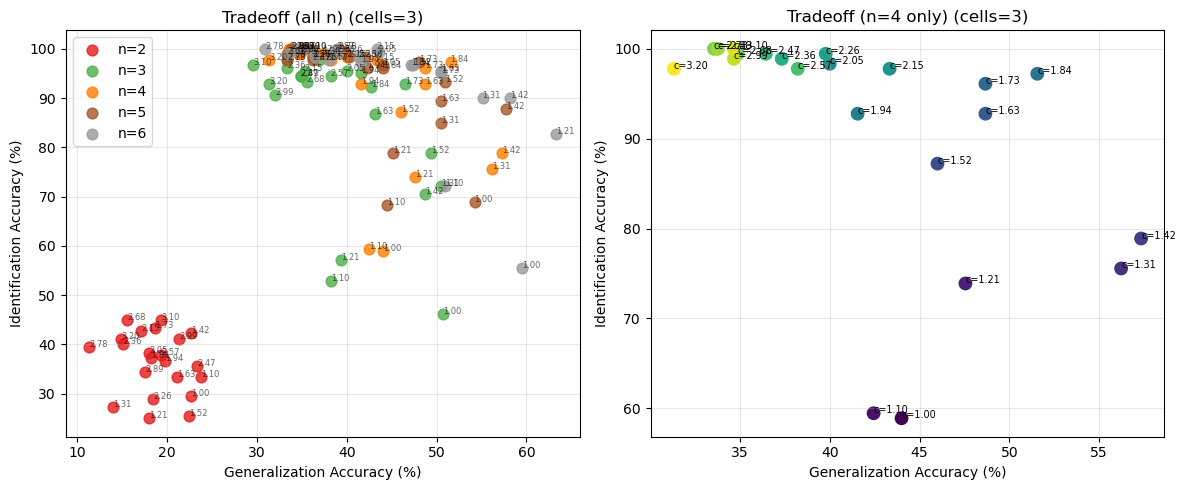

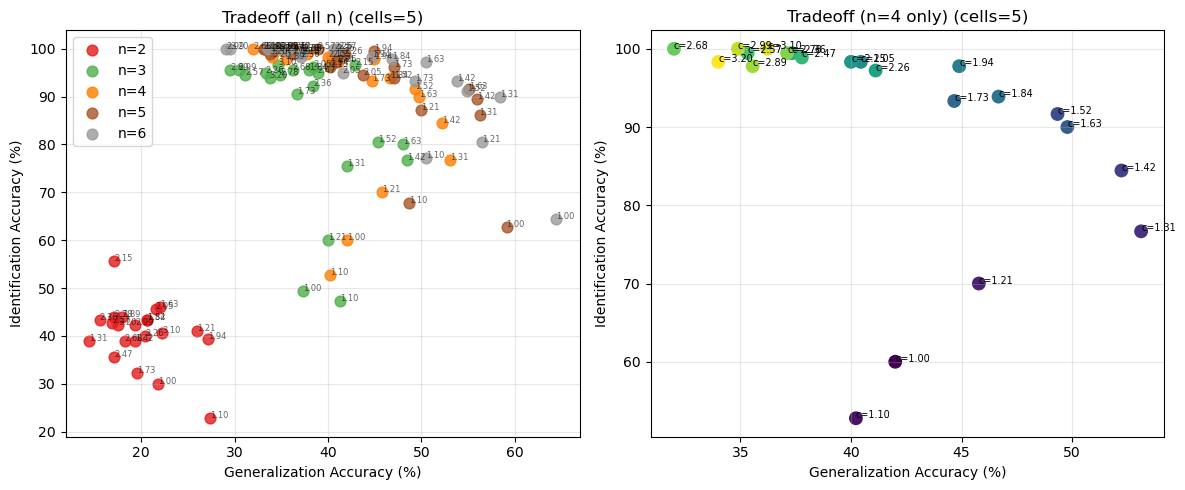

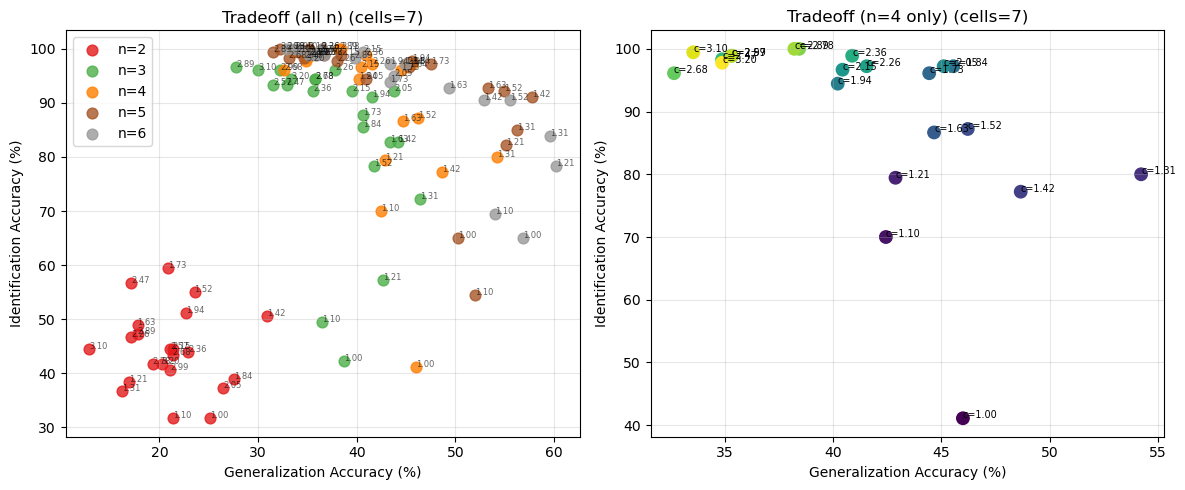

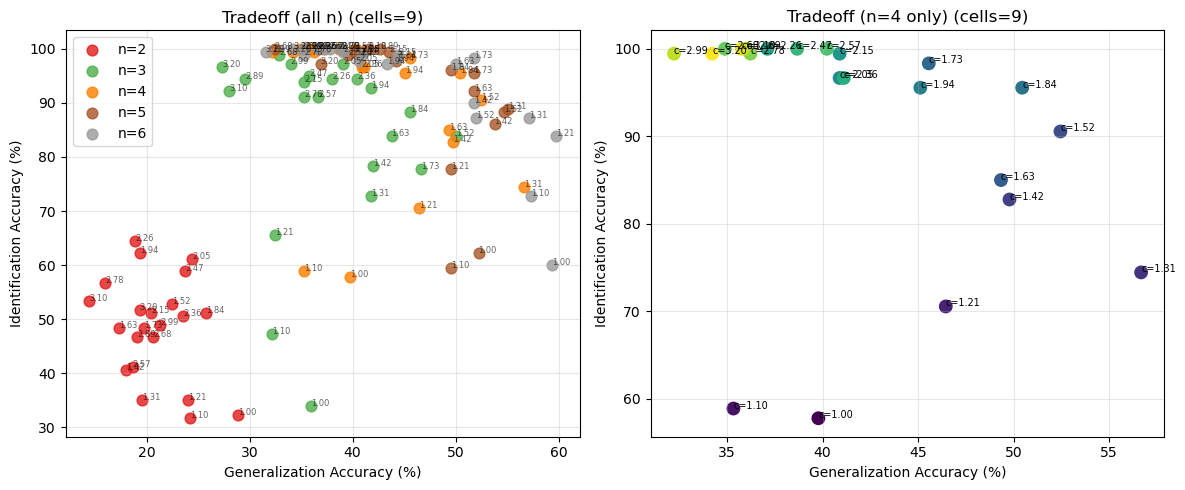

In [8]:
run_breakit_cell("cells")

### Input distributions

In [ ]:
run_breakit_cell("distributions")